In [1]:
import arviz as az
import pystan
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import warnings

logsumexp = az.stats.stats_utils.logsumexp

In [2]:
xdata = np.linspace(0,50,100)
b0, b1, sigma = -2, 1, 3
ydata = np.random.normal(loc=b1*xdata + b0, scale=sigma)

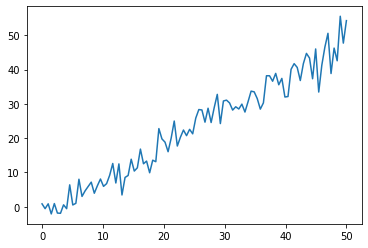

In [3]:
plt.plot(xdata, ydata)

In [4]:
refit_lr_code = """
data {
  int<lower=0> N;
  vector[N] x;
  vector[N] y;
  int<lower=0> N_ex;
  vector[N_ex] x_ex;
  vector[N_ex] y_ex;
}

parameters {
  real b0;
  real b1;
  real<lower=0> sigma_e;
}

model {
  b0 ~ normal(0, 10);
  b1 ~ normal(0, 10);
  sigma_e ~ normal(0, 10);
  for (i in 1:N) {
    y[i] ~ normal(b0 + b1 * x[i], sigma_e);
  }
  
}

generated quantities {
    vector[N] log_lik;
    vector[N_ex] log_lik_ex;
    vector[N] y_hat;
    for (i in 1:N) {
        log_lik[i] = normal_lpdf(y[i] | b0 + b1 * x[i], sigma_e);
        y_hat[i] = normal_rng(b0 + b1 * x[i], sigma_e);
    }
    for (j in 1:N_ex) {
        log_lik_ex[j] = normal_lpdf(y_ex[j] | b0 + b1 * x_ex[j], sigma_e);
    }
}
"""

In [5]:
sm = pystan.StanModel(model_code=refit_lr_code)

INFO:pystan:COMPILING THE C++ CODE FOR MODEL anon_model_070324b45bacc60e55b31d055c7d0d8f NOW.


In [6]:
data_dict = {
    'N': len(ydata),
    'y': ydata,
    'x': xdata, 
    "N_ex": 0,
    "x_ex": [],
    "y_ex": [],
}
sample_kwargs = {"iter": 1000, "chains": 4}
fit = sm.sampling(data=data_dict, **sample_kwargs)

In [7]:
dims = {"y":["time"], "x":["time"], "log_likelihood": ["time"], "y_hat": ["time"]}
idata_kwargs = {
    "posterior_predictive": ['y_hat', "log_lik_ex"],
    "observed_data": ['y', 'x'],
    "log_likelihood": 'log_lik',
    "dims": dims,
}
idata = az.from_pystan(
    posterior=fit,
    **idata_kwargs
)

In [8]:
idata.posterior

<xarray.Dataset>
Dimensions:  (chain: 4, draw: 500)
Coordinates:
  * chain    (chain) int64 0 1 2 3
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 ... 492 493 494 495 496 497 498 499
Data variables:
    b0       (chain, draw) float64 -1.672 -2.173 -3.37 ... -2.981 -2.677 -2.909
    b1       (chain, draw) float64 0.9903 0.9904 1.047 ... 1.011 1.018 1.025
    sigma_e  (chain, draw) float64 3.197 3.114 3.356 3.171 ... 3.194 3.176 3.123
Attributes:
    created_at:                 2019-07-29T12:06:14.265082
    inference_library:          pystan
    inference_library_version:  2.19.0.0

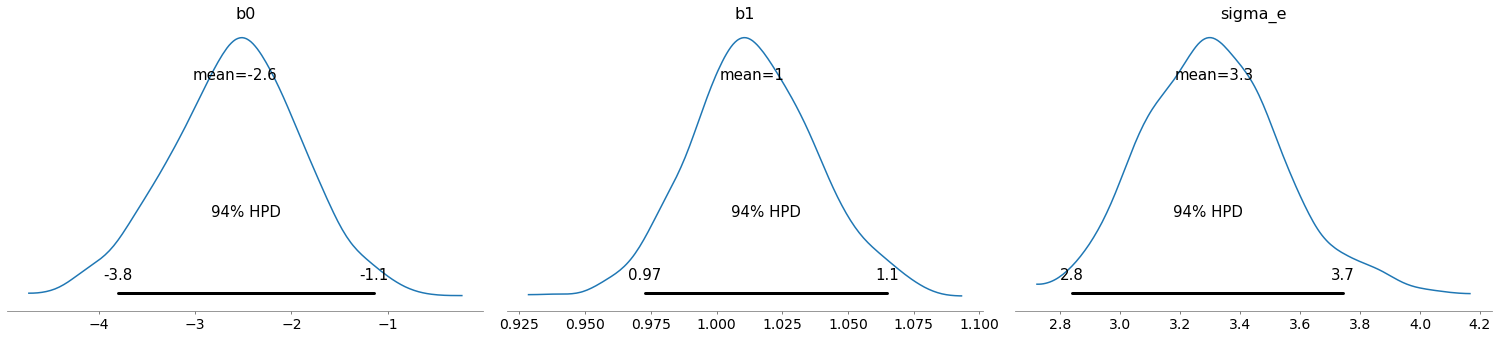

In [9]:
az.plot_posterior(idata);

In [10]:
class PyStanSamplingWrapper(az.SamplingWrapper):
    
    def sel_observations(self, idx):
        obs_data = self.idata_orig.observed_data
        xdata = obs_data.x.values
        ydata = obs_data.y.values
        mask = np.full_like(xdata, True, dtype=bool)
        mask[idx] = False
        N_obs = len(mask)
        N_ex = np.sum(~mask)
        observations = {
            "N": N_obs-N_ex,
            "x": xdata[mask],
            "y": ydata[mask],
            "N_ex": N_ex,
            "x_ex": xdata[~mask],
            "y_ex": ydata[~mask]
        }
        return observations, observations
    
    def sample(self, modified_observed_data):
        """Could be generalized"""
        fit = self.model.sampling(data=modified_observed_data, **self.sample_kwargs)
        return fit
    
    def get_inference_data(self, fit):
        """Could be generalized"""
        idata = az.from_pystan(
            posterior=fit,
            **self.idata_kwargs
        )
        return idata
    
    def log_likelihood__i(self, excluded_obs, idata__i):
        return idata__i.posterior_predictive.log_lik_ex
        

In [11]:
pystan_wrapper = PyStanSamplingWrapper(
    sm, 
    idata_orig=idata, 
    sample_kwargs=sample_kwargs, 
    idata_kwargs=idata_kwargs
)

In [12]:
def reloo(wrapper, loo_orig=None):
    if loo_orig is None:
        loo_orig = az.loo(wrapper.idata_orig, pointwise=True)
    reloo = loo_orig.copy()
    khats = reloo.pareto_k
    loo_i = reloo.loo_i
    scale = loo_orig.loo_scale
    if scale.lower() == "deviance":
        scale_value = -2
    elif scale.lower() == "log":
        scale_value = 1
    elif scale.lower() == "negative_log":
        scale_value = -1
    lppd_orig = loo_orig.p_loo + loo_orig.loo / scale_value
    n_data_points = loo_orig.n_data_points
    if np.any(khats>.7):
        lppd = np.empty(np.sum(khats.values>.7))
        for count, idx in enumerate(np.argwhere(khats.values>.7)):
            new_obs, excluded_obs = wrapper.sel_observations(idx)
            fit = wrapper.sample(new_obs)
            idata_idx = wrapper.get_inference_data(fit)
            log_like_idx = wrapper.log_likelihood__i(excluded_obs, idata_idx).values.flatten()
            loo_lppd_idx = scale_value * logsumexp(log_like_idx, b_inv=len(log_like_idx))
            khats[idx] = 0
            loo_i[idx] = loo_lppd_idx
            log_likelihood_i = idata_idx.sample_stats.log_likelihood.stack(sample=("chain", "draw"))
            log_likelihood = np.concatenate((log_likelihood_i.values, log_like_idx[None, ...]), axis=0)
            print(log_likelihood.shape)
            lppd[count] = np.sum(
                az.wrap_xarray_ufunc(
                    logsumexp,
                    log_likelihood,
                    func_kwargs={"b_inv": loo_orig.n_samples},
                    ufunc_kwargs={"n_dims": 1, "ravel": False},
                    input_core_dims= [["sample"]],
                )
            )
        reloo.loo = loo_i.values.sum()
        reloo.loo_se = (n_data_points * np.var(loo_i.values)) ** 0.5
        reloo.p_loo = lppd.mean() - reloo.loo / scale_value
        print("lppd_orig  :  recalculated")
        print(lppd_orig, lppd.mean())
        print(lppd_orig - reloo.loo / scale_value, reloo.p_loo)
        return reloo
    else:
        print("No problematic observations")
        return loo_orig

In [13]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    loo_orig = az.loo(idata, pointwise=True, scale="log")
loo_orig

/home/oriol/Public/arviz/arviz/stats/stats_utils.py:472: NumbaWarning: 
Compilation is falling back to object mode WITH looplifting enabled because Function "histogram" failed type inference due to: non-precise type pyobject
[1] During: typing of argument at /home/oriol/Public/arviz/arviz/stats/stats_utils.py (474)

File "arviz/stats/stats_utils.py", line 474:
def histogram(data):
    kcounts, _ = np.histogram(data, bins=[-np.Inf, 0.5, 0.7, 1, np.Inf])
    ^

  @conditional_jit
/home/oriol/venvs/arviz-dev/lib/python3.6/site-packages/numba/compiler.py:725: NumbaWarning: Function "histogram" was compiled in object mode without forceobj=True.

File "arviz/stats/stats_utils.py", line 473:
@conditional_jit
def histogram(data):
^

  self.func_ir.loc))
/home/oriol/venvs/arviz-dev/lib/python3.6/site-packages/numba/compiler.py:734: NumbaDeprecationWarning: 
Fall-back from the nopython compilation path to the object mode compilation path has been detected, this is deprecated behaviour.

For more

Computed from 2000 by 100 log-likelihood matrix

         Estimate       SE
elpd_loo  -262.58     7.72
p_loo        3.40        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)      100  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [14]:
loo_orig.pareto_k[47] = .8
loo_orig.pareto_k[93] = 1.3
reloo_data = reloo(pystan_wrapper, loo_orig=loo_orig)

(100, 2000)
(100, 2000)
lppd_orig  :  recalculated
-259.18542033806517 -259.16201770689577
3.396408253549282 3.419810884718686


In [15]:
az.ELPDData(reloo_data)

Computed from 2000 by 100 log-likelihood matrix

         Estimate       SE
elpd_loo  -262.58     7.72
p_loo        3.42        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)      100  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%